# Crop Recommendation with k-Nearest Neighbors

This notebook walks through **supervised k-NN classification** on the
UCI-style **Crop Recommendation** dataset (soil chemistry, weather,
and agronomic targets for 22 crop labels). The workflow mirrors the
structure used in reference course materials: a clear pipeline from
raw data to tuned model, plots, and a written discussion of results.

The first code cell imports libraries and sets plot defaults. **Notebook outline:**

1. Load data and basic quality checks  
2. Exploratory analysis (labels and feature scales)  
3. Train / test split and feature standardization  
4. Baseline: raw features vs scaled features  
5. Hyperparameter tuning with `GridSearchCV`  
6. Test-set evaluation and confusion matrix  
7. Visualizations  
8. Discussion and limitations


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from rice_ml.processing.datasets import find_data_file

np.random.seed(0)
plt.rcParams["figure.figsize"] = (8, 4.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25


## 1. Load data and quality checks

We read `Crop_recommendation.csv` via `find_data_file` so the notebook
runs from the repo root, from this folder, or from Jupyter with any
working directory.


In [2]:
from rice_ml.supervised_learning.knn import KNeighborsClassifier
from rice_ml.processing.pre_processing import StandardScaler, LabelEncoder, train_test_split
from sklearn.model_selection import cross_val_score, GridSearchCV
from rice_ml.processing.post_processing import accuracy_score, confusion_matrix

path = find_data_file("Crop_recommendation.csv")
df = pd.read_csv(path)

feature_cols = [c for c in df.columns if c != "label"]
print("Path:", path)
print("Shape (rows, cols):", df.shape)
print("Features:", feature_cols)
print("Number of crop classes:", df["label"].nunique())
print("\nDtypes:\n", df.dtypes)
print("\nMissing values per column:\n", df.isna().sum())
df.head()


Path: /workspace/data/Crop_recommendation.csv
Shape (rows, cols): (2200, 8)
Features: ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']
Number of crop classes: 22

Dtypes:
 N                int64
P                int64
K                int64
temperature    float64
humidity       float64
ph             float64
rainfall       float64
label              str
dtype: object

Missing values per column:
 N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64


,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


## 2. Exploratory analysis

k-NN uses **distance** in feature space. If one variable has a much
larger numeric range than the others, it dominates the metric before we
even think about agronomy. The tables and plots below make that
imbalance visible.


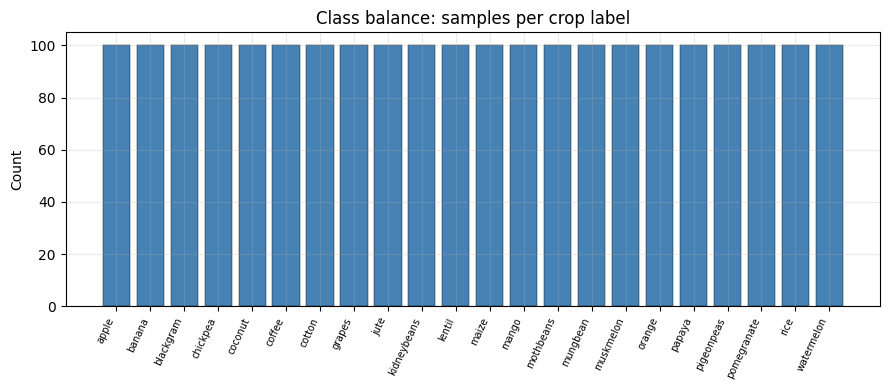

,min,max,mean,std
N,0.00,140.00,50.55,36.92
P,5.00,145.00,53.36,32.99
K,5.00,205.00,48.15,50.65
temperature,8.83,43.68,25.62,5.06
humidity,14.26,99.98,71.48,22.26
ph,3.50,9.94,6.47,0.77
rainfall,20.21,298.56,103.46,54.96


In [3]:
fig, ax = plt.subplots(figsize=(9, 4))
counts = df["label"].value_counts().sort_index()
ax.bar(range(len(counts)), counts.values, color="steelblue", edgecolor="k", linewidth=0.3)
ax.set_xticks(range(len(counts)))
ax.set_xticklabels(counts.index, rotation=65, ha="right", fontsize=7)
ax.set_ylabel("Count")
ax.set_title("Class balance: samples per crop label")
plt.tight_layout()
plt.show()

summary = df[feature_cols].describe().T[["min", "max", "mean", "std"]].round(2)
summary


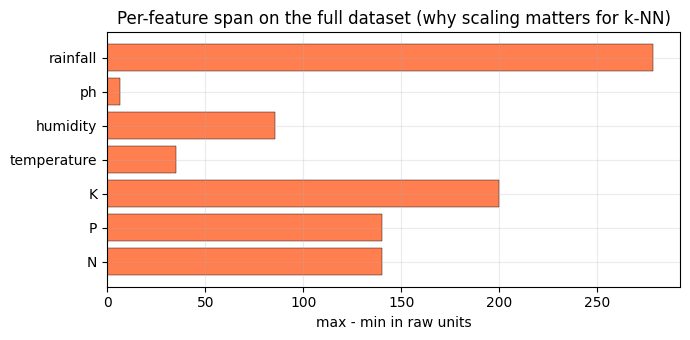

In [4]:
# Feature ranges differ by orders of magnitude (e.g. rainfall vs N, P, K)
rng = df[feature_cols].max() - df[feature_cols].min()
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.barh(rng.index.astype(str), rng.values, color="coral", edgecolor="k", linewidth=0.3)
ax.set_xlabel("max - min in raw units")
ax.set_title("Per-feature span on the full dataset (why scaling matters for k-NN)")
plt.tight_layout()
plt.show()


## 3. Train / test split and scaling

We stratify on `label` so every crop appears in both train and test
splits. `StandardScaler` is fit **only on the training fold** and applied
to the test set to mimic honest deployment practice.


In [5]:
X = df[feature_cols].to_numpy(dtype=float)
le = LabelEncoder().fit(df["label"])
y = le.transform(df["label"])

X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=0,
)
print("Train shape:", X_tr.shape, "  Test shape:", X_te.shape)

scaler = StandardScaler().fit(X_tr)
X_tr_s = scaler.transform(X_tr)
X_te_s = scaler.transform(X_te)


Train shape: (1650, 7)   Test shape: (550, 7)


## 4. Baseline: raw vs scaled Euclidean k-NN

Same $k$, same algorithm — only the preprocessing changes. This is the
quickest way to see that **distance is not meaningful on raw agronomic
units** until we put variables on a comparable scale.


In [6]:
k_demo = 5
raw_score = (
    KNeighborsClassifier(n_neighbors=k_demo, metric="euclidean")
    .fit(X_tr, y_tr)
    .score(X_te, y_te)
)
scaled_score = (
    KNeighborsClassifier(n_neighbors=k_demo, metric="euclidean")
    .fit(X_tr_s, y_tr)
    .score(X_te_s, y_te)
)
print(f"k = {k_demo}, uniform weights, Euclidean metric")
print(f"  Test accuracy (raw features)    = {raw_score:.4f}")
print(f"  Test accuracy (scaled features)  = {scaled_score:.4f}")


k = 5, uniform weights, Euclidean metric
  Test accuracy (raw features)    = 0.9782
  Test accuracy (scaled features)  = 0.9800


## 5. Hyperparameter tuning (`GridSearchCV`)

We search over:

- **`n_neighbors`** — bias–variance trade-off (small $k$ reacts to noise;
  large $k$ smooths decision boundaries).  
- **`weights`** — `'uniform'` vs `'distance'` (weight closer neighbors more).  
- **`metric`** — Euclidean vs Manhattan (different geometry in $\mathbb{R}^7$).

`GridSearchCV` runs 5-fold cross-validation on the **training split** for
every combination and keeps the parameter set with the highest mean CV
score. This mirrors the “pipeline + tuning” step in regression-style k-NN
notebooks, adapted to our from-scratch `rice_ml` API.


In [7]:
param_grid = {
    "n_neighbors": list(range(1, 26, 2)),
    "weights": ["uniform", "distance"],
    "metric": ["euclidean", "manhattan"],
}
base = KNeighborsClassifier()
search = GridSearchCV(base, param_grid, cv=5).fit(X_tr_s, y_tr)

print("Best CV mean accuracy:", round(search.best_score_, 4))
print("Best parameters:", search.best_params_)

rows = []
for r in search.cv_results_:
    p = r["params"]
    rows.append({
        "n_neighbors": p["n_neighbors"],
        "weights": p["weights"],
        "metric": p["metric"],
        "mean_cv_acc": round(r["mean_score"], 4),
    })
cv_table = pd.DataFrame(rows).sort_values("mean_cv_acc", ascending=False)
cv_table.head(12)


Best CV mean accuracy: 0.9782
Best parameters: {'n_neighbors': 3, 'weights': 'distance', 'metric': 'manhattan'}


,n_neighbors,weights,metric,mean_cv_acc
19,9,distance,manhattan,0.9782
7,3,distance,manhattan,0.9782
3,1,distance,manhattan,0.9776
5,3,uniform,manhattan,0.9776
11,5,distance,manhattan,0.9770
1,1,uniform,manhattan,0.9758
9,5,uniform,manhattan,0.9739
6,3,distance,euclidean,0.9739
15,7,distance,manhattan,0.9733
14,7,distance,euclidean,0.9733


## 6. Test-set evaluation

The winning estimator is already refit on the **full training split**
inside `GridSearchCV.fit`. We report hold-out accuracy and inspect a
multi-class confusion matrix (rows = true crop, columns = predicted crop).


In [8]:
best = search.best_estimator_
y_pred = best.predict(X_te_s)
test_acc = accuracy_score(y_te, y_pred)
print(f"Hold-out test accuracy: {test_acc:.4f}")

labels_int = np.arange(len(le.classes_))
cm = confusion_matrix(y_te, y_pred, labels=labels_int)
cm_df = pd.DataFrame(cm, index=le.classes_, columns=le.classes_)
cm_df.iloc[:8, :8]  # preview; full matrix is large (22 x 22)


Hold-out test accuracy: 0.9836


,apple,banana,blackgram,chickpea,coconut,coffee,cotton,grapes
apple,25,0,0,0,0,0,0,0
banana,0,25,0,0,0,0,0,0
blackgram,0,0,24,0,0,0,0,0
chickpea,0,0,0,25,0,0,0,0
coconut,0,0,0,0,25,0,0,0
coffee,0,0,0,0,0,25,0,0
cotton,0,0,0,0,0,0,25,0
grapes,0,0,0,0,0,0,0,25


## 7. Visualizations

**Cross-validation curve** for the best `(weights, metric)` pair: mean
accuracy vs $k$. **Confusion matrix** as a heatmap highlights systematic
confusions between agronomically similar crops.


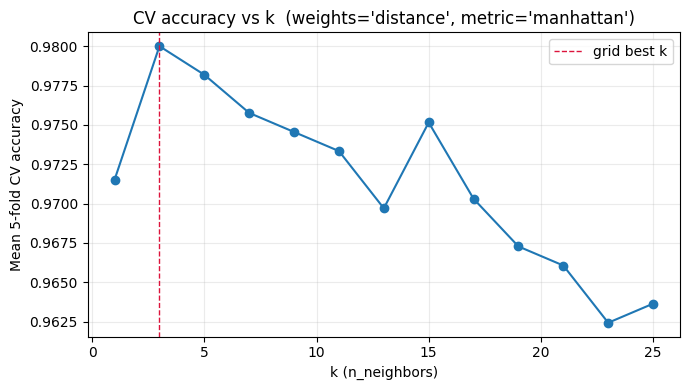

In [9]:
best_w = search.best_params_["weights"]
best_m = search.best_params_["metric"]
ks_tune = param_grid["n_neighbors"]
cv_curve = [
    cross_val_score(
        KNeighborsClassifier(n_neighbors=k, weights=best_w, metric=best_m),
        X_tr_s,
        y_tr,
        cv=5,
    ).mean()
    for k in ks_tune
]

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(ks_tune, cv_curve, marker="o")
ax.axvline(search.best_params_["n_neighbors"], color="crimson", ls="--", lw=1, label="grid best k")
ax.set_xlabel("k (n_neighbors)")
ax.set_ylabel("Mean 5-fold CV accuracy")
ax.set_title(f"CV accuracy vs k  (weights={best_w!r}, metric={best_m!r})")
ax.legend()
plt.tight_layout()
plt.show()


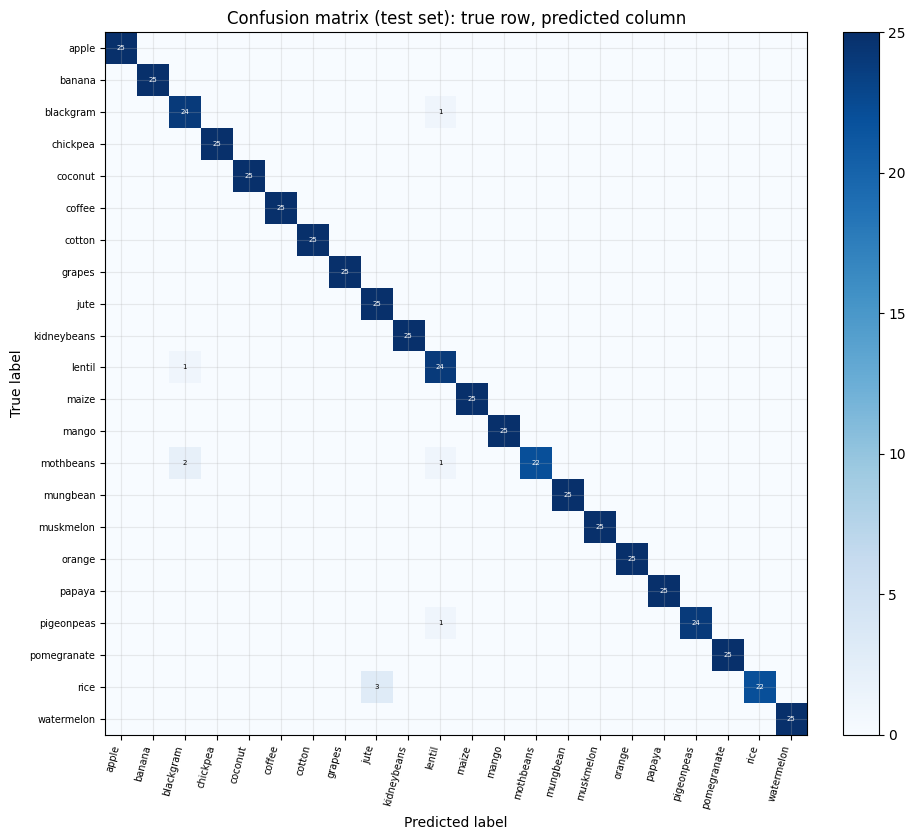

In [10]:
fig, ax = plt.subplots(figsize=(10, 8.5))
im = ax.imshow(cm, interpolation="nearest", cmap="Blues")
ax.set_title("Confusion matrix (test set): true row, predicted column")
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
tick_marks = np.arange(len(le.classes_))
ax.set_xticks(tick_marks)
ax.set_yticks(tick_marks)
ax.set_xticklabels(le.classes_, rotation=75, ha="right", fontsize=7)
ax.set_yticklabels(le.classes_, fontsize=7)
ax.set_ylabel("True label")
ax.set_xlabel("Predicted label")

thresh = cm.max() / 2.0
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        val = cm[i, j]
        if val == 0:
            continue
        ax.text(
            j,
            i,
            format(val, "d"),
            ha="center",
            va="center",
            color="white" if val > thresh else "black",
            fontsize=5,
        )
plt.tight_layout()
plt.show()


In [11]:
# Crops with highest misclassification rate (off-diagonal mass)
wrong = cm.sum(axis=1) - np.diag(cm)
total_per_class = cm.sum(axis=1)
rate = np.divide(wrong, np.maximum(total_per_class, 1))
misrank = (
    pd.Series(rate, index=le.classes_)
    .sort_values(ascending=False)
    .head(8)
    .rename("misclassification_rate")
)
print("Hardest true classes (share of test rows not predicted correctly):")
print(misrank.round(3))


Hardest true classes (share of test rows not predicted correctly):
rice          0.12
mothbeans     0.12
lentil        0.04
pigeonpeas    0.04
blackgram     0.04
apple         0.00
coffee        0.00
coconut       0.00
Name: misclassification_rate, dtype: float64


## 8. Discussion

**Model performance (test set).** The printed summary below is generated
from the actual run so it stays consistent with the plots.

**Scaling.** Large-span features such as rainfall would dominate Euclidean
distance if we skipped standardization; the raw-vs-scaled baseline
section quantifies how much accuracy we recover.

**Choice of $k$ and metric.** Cross-validation scores typically rise as we
add neighbors (variance drops), then plateau or dip once neighborhoods
become too heterogeneous across 22 classes. Manhattan distance treats
axis-aligned differences literally; Euclidean rotation is the default
geometry for many tabular k-NN baselines.

**Confusion structure.** Off-diagonal mass often clusters on agronomically
similar crops that share overlapping ranges of N, P, K, humidity, and
rainfall — exactly where a purely local method like k-NN can blur class
boundaries.

**Limitations.** k-NN stores the entire training set, predicts in
time roughly linear in training size, and does not learn an explicit
low-dimensional boundary the way parametric models do. For this modest
dataset those costs are acceptable; at internet scale they would not be.


In [12]:
print("--- Auto-generated results summary ---")
print(f"Best hyperparameters: {search.best_params_}")
print(f"Best 5-fold CV mean accuracy (train split): {search.best_score_:.4f}")
print(f"Hold-out test accuracy: {test_acc:.4f}")
print(f"Baseline k={k_demo} test accuracy — raw: {raw_score:.4f}, scaled: {scaled_score:.4f}")


--- Auto-generated results summary ---
Best hyperparameters: {'n_neighbors': 3, 'weights': 'distance', 'metric': 'manhattan'}
Best 5-fold CV mean accuracy (train split): 0.9782
Hold-out test accuracy: 0.9836
Baseline k=5 test accuracy — raw: 0.9782, scaled: 0.9800
